**Chapter 2 – End-to-end Machine Learning project**

In [565]:
print("Welcome to Machine Learning!")

Welcome to Machine Learning!


**Tirth Ritesh Baldia**

**Use case**: Predict player market value in euros from performance and club context.

**Dataset**: Transfermarkt player data (valuations, players, appearances, clubs, competitions).

## 1. Problem Framing

**Objective**: Build a regression model to estimate `market_value_in_eur` for a player at a given time.

**Why it matters**: Helps scouting, valuation, and budget planning by providing data-driven estimates.

**Type of problem**: Supervised regression.

**Success metrics**: RMSE and MAE on a held-out test set.

**Constraints**:
- Market values are noisy and skewed.
- Many categorical features with high cardinality.
- Sparse player appearances for some seasons.


## 2. Setup

In [566]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
np.random.seed(42)


## 3. Data Acquisition and Loading

In [567]:
def keep_existing_cols(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

def load_and_merge_transfermarkt(data_dir, include_competitions=True):
    valuations = pd.read_csv(os.path.join(data_dir, 'player_valuations.csv'))
    players = pd.read_csv(os.path.join(data_dir, 'players.csv'))
    appearances = pd.read_csv(os.path.join(data_dir, 'appearances.csv'))
    clubs = pd.read_csv(os.path.join(data_dir, 'clubs.csv'))

    competitions = None
    if include_competitions and os.path.exists(os.path.join(data_dir, 'competitions.csv')):
        competitions = pd.read_csv(os.path.join(data_dir, 'competitions.csv'))

    valuations['date'] = pd.to_datetime(valuations['date'], errors='coerce')
    appearances['date'] = pd.to_datetime(appearances['date'], errors='coerce')

    df = valuations.copy()

    player_cols = [
        'player_id',
        'country_of_citizenship',
        'position',
        'sub_position',
        'foot',
        'height_in_cm',
        'current_club_domestic_competition_id',
        'current_club_name',
    ]
    df = df.merge(keep_existing_cols(players, player_cols), on='player_id', how='left')

    appearances['season_year'] = appearances['date'].dt.year
    df['season_year'] = df['date'].dt.year

    app_cols = [
        'player_id',
        'season_year',
        'game_id',
        'minutes_played',
        'goals',
        'assists',
        'yellow_cards',
        'red_cards',
    ]
    appearances_small = keep_existing_cols(appearances, app_cols)

    agg_apps = (
        appearances_small.groupby(['player_id', 'season_year'])
        .agg(
            games_played=('game_id', 'nunique'),
            minutes_played=('minutes_played', 'sum'),
            goals=('goals', 'sum'),
            assists=('assists', 'sum'),
            yellow_cards=('yellow_cards', 'sum'),
            red_cards=('red_cards', 'sum'),
        )
        .reset_index()
    )

    df = df.merge(agg_apps, on=['player_id', 'season_year'], how='left')

    club_cols = [
        'club_id',
        'squad_size',
        'average_age',
        'foreigners_number',
        'foreigners_percentage',
        'national_team_players',
        'stadium_seats',
        'total_market_value',
    ]
    clubs_small = keep_existing_cols(clubs, club_cols)

    if 'current_club_id' in df.columns and 'club_id' in clubs_small.columns:
        df['current_club_id'] = pd.to_numeric(df['current_club_id'], errors='coerce')
        clubs_small['club_id'] = pd.to_numeric(clubs_small['club_id'], errors='coerce')
        df = df.merge(clubs_small, left_on='current_club_id', right_on='club_id', how='left')
        df = df.drop(columns=['club_id'], errors='ignore')

    if include_competitions and competitions is not None:
        comp_cols = [
            'domestic_league_code',
            'country_name',
            'confederation',
            'is_major_national_league',
            'type',
            'sub_type',
        ]
        competitions_small = keep_existing_cols(competitions, comp_cols)

        if 'type' in competitions_small.columns:
            competitions_small = competitions_small[competitions_small['type'] == 'domestic_league']

        if 'sub_type' in competitions_small.columns:
            first_tier = competitions_small[competitions_small['sub_type'] == 'first_tier']
            if len(first_tier) > 0:
                competitions_small = first_tier

        competitions_small = competitions_small.drop_duplicates(
            subset=['domestic_league_code'], keep='first'
        )

        if 'player_club_domestic_competition_id' in df.columns:
            df = df.merge(
                competitions_small,
                left_on='player_club_domestic_competition_id',
                right_on='domestic_league_code',
                how='left'
            ).drop(columns=['domestic_league_code'], errors='ignore')

    df = df.drop_duplicates(subset=['player_id', 'date'], keep='first')
    return df

# Download dataset (or set local path if already available)
path = kagglehub.dataset_download('davidcariboo/player-scores')

# Example local override:
# path = '/path/to/player-scores'

df_merged = load_and_merge_transfermarkt(path, include_competitions=True)
df_merged.head()


,player_id,date,market_value_in_eur,current_club_name_x,current_club_id,player_club_domestic_competition_id,country_of_citizenship,position,sub_position,foot,height_in_cm,current_club_domestic_competition_id,current_club_name_y,season_year,games_played,minutes_played,goals,assists,yellow_cards,red_cards,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_seats,total_market_value,country_name,confederation,is_major_national_league,type,sub_type
0,405973,2000-01-20,150000,Unknown,3057,BE1,Togo,Attack,Left Winger,NaN,181.0,BE1,Royal Standard Club de Liège,2000,NaN,NaN,NaN,NaN,NaN,NaN,31.0,26.1,21.0,67.7,6.0,27221.0,NaN,Belgium,europa,False,domestic_league,first_tier
1,342216,2001-07-20,100000,Unknown,1241,SC1,France,Defender,Left-Back,left,181.0,SC1,Livingston Football Club,2001,NaN,NaN,NaN,NaN,NaN,NaN,27.0,29.1,14.0,51.9,3.0,9512.0,NaN,Scotland,europa,False,domestic_league,first_tier
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1,Romania,Midfield,Attacking Midfield,left,168.0,TR1,Çaykur Rizespor Kulübü,2003,NaN,NaN,NaN,NaN,NaN,NaN,25.0,26.5,15.0,60.0,8.0,14879.0,NaN,Turkey,europa,False,domestic_league,first_tier
3,6893,2003-12-15,900000,Galatasaray,984,GB1,Romania,Defender,Centre-Back,right,188.0,GB1,West Bromwich Albion,2003,NaN,NaN,NaN,NaN,NaN,NaN,25.0,27.8,8.0,32.0,4.0,26850.0,NaN,England,europa,True,domestic_league,first_tier
4,3333,2004-04-10,7500000,Newcastle United,399,GB1,England,Midfield,Central Midfield,right,175.0,GB1,Brighton and Hove Albion Football Club,2004,NaN,NaN,NaN,NaN,NaN,NaN,26.0,27.1,20.0,76.9,11.0,37890.0,NaN,England,europa,True,domestic_league,first_tier


## 4. Data Exploration (Structure, Types, etc)

In [568]:
print('Final shape:', df_merged.shape)
print('Duplicate (player_id,date) rows:', df_merged.duplicated(['player_id', 'date']).sum())


Final shape: (448187, 32)
Duplicate (player_id,date) rows: 0


In [569]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448187 entries, 0 to 448186
Data columns (total 32 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   player_id                             448187 non-null  int64         
 1   date                                  448187 non-null  datetime64[ns]
 2   market_value_in_eur                   448187 non-null  int64         
 3   current_club_name_x                   448187 non-null  object        
 4   current_club_id                       448187 non-null  int64         
 5   player_club_domestic_competition_id   417153 non-null  object        
 6   country_of_citizenship                443001 non-null  object        
 7   position                              448187 non-null  object        
 8   sub_position                          447367 non-null  object        
 9   foot                                  434005 non-null  obje

In [570]:
df_merged.describe(include='all').T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
player_id,448187.0,NaN,NaN,NaN,209947.598226,10.0,55959.0,146854.0,303412.0,1497653.0,201515.680685
date,448187,NaN,NaN,NaN,2017-08-11 01:11:11.545583104,2000-01-20 00:00:00,2014-03-31 00:00:00,2018-05-27 00:00:00,2021-06-07 00:00:00,2026-02-15 00:00:00,NaN
market_value_in_eur,448187.0,NaN,NaN,NaN,2091158.159427,10000.0,200000.0,500000.0,1500000.0,200000000.0,5957661.880956
current_club_name_x,448187,6551,Without Club,3776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_club_id,448187.0,NaN,NaN,NaN,4558.615721,1.0,380.0,1063.0,3302.0,138023.0,10410.099207
player_club_domestic_competition_id,417153,14,IT1,47069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_citizenship,443001,184,Spain,31486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,448187,5,Defender,144591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_position,447367,13,Centre-Back,81760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
foot,434005,3,right,305698,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Target Distribution

In [571]:
df_merged['market_value_in_eur'].describe()

count    4.481870e+05
mean     2.091158e+06
std      5.957662e+06
min      1.000000e+04
25%      2.000000e+05
50%      5.000000e+05
75%      1.500000e+06
max      2.000000e+08
Name: market_value_in_eur, dtype: float64

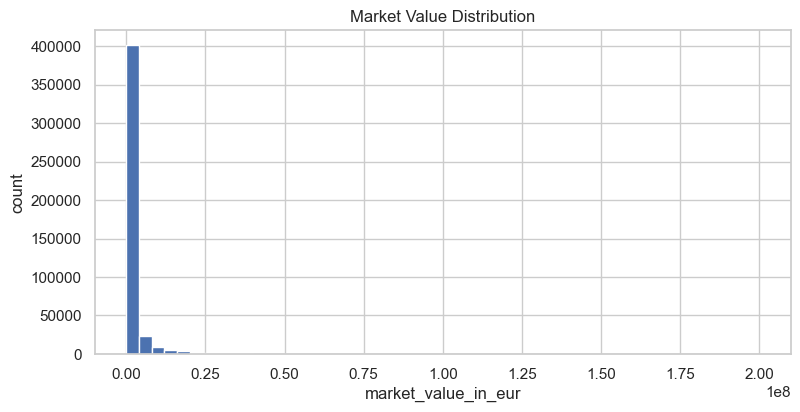

In [572]:
plt.figure(figsize=(8, 4))
plt.hist(df_merged['market_value_in_eur'].dropna(), bins=50)
plt.title('Market Value Distribution')
plt.xlabel('market_value_in_eur')
plt.ylabel('count')
plt.show()


### Missing Values

In [573]:
missing = df_merged.isna().sum().sort_values(ascending=False)
missing.head(15)

total_market_value          448187
goals                       263031
minutes_played              263031
games_played                263031
red_cards                   263031
assists                     263031
yellow_cards                263031
foreigners_percentage        68884
average_age                  57904
stadium_seats                31034
country_name                 31034
foreigners_number            31034
squad_size                   31034
confederation                31034
is_major_national_league     31034
dtype: int64

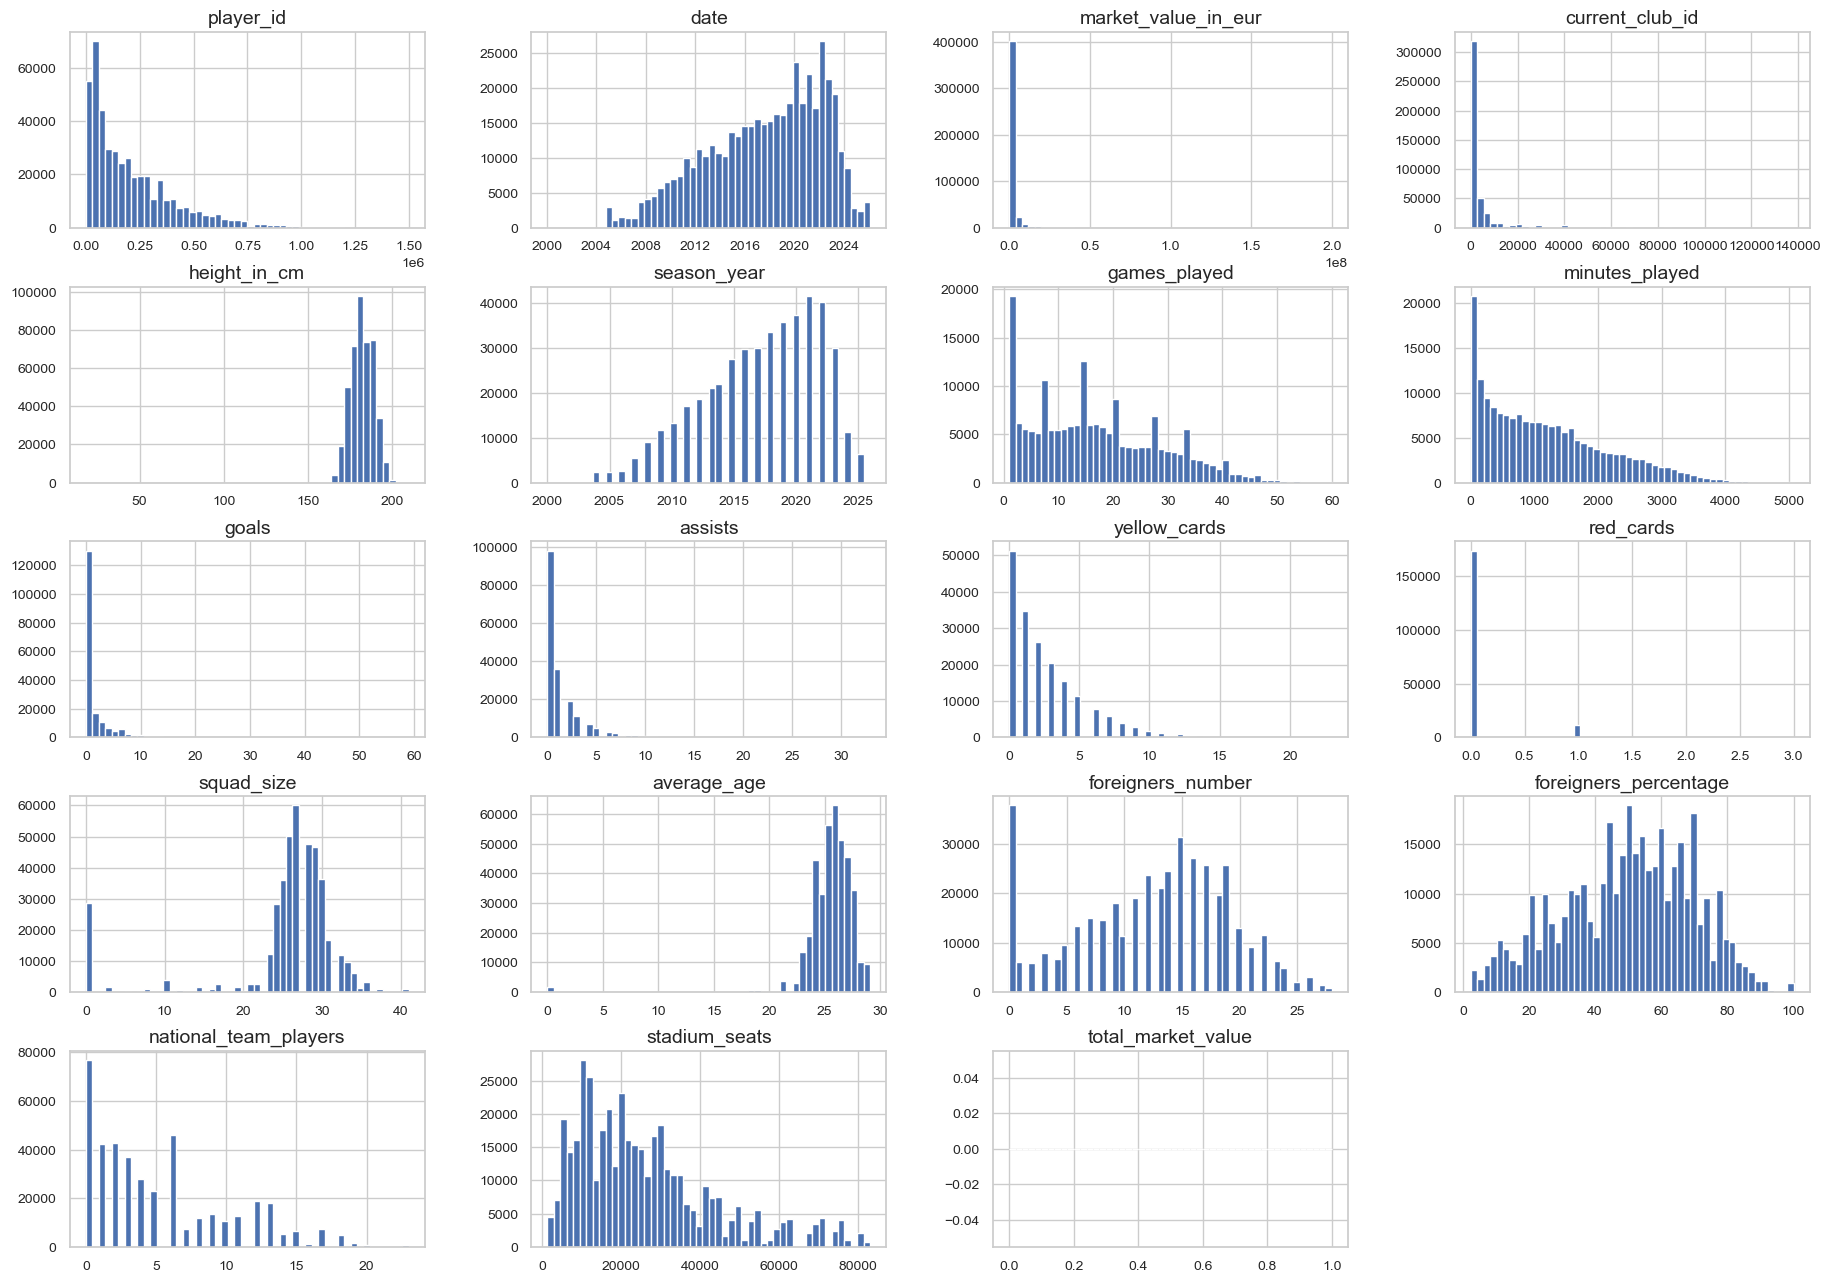

In [574]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df_merged.hist(bins=50, figsize=(20, 15))
plt.show()

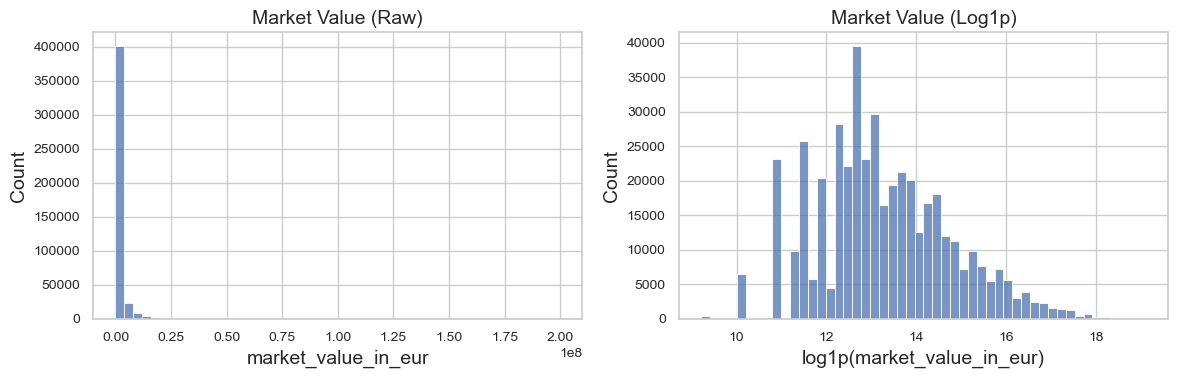

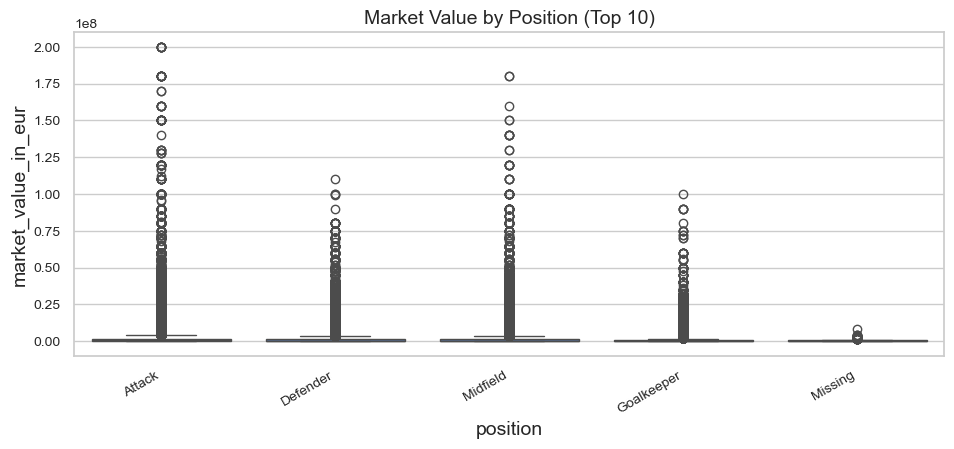

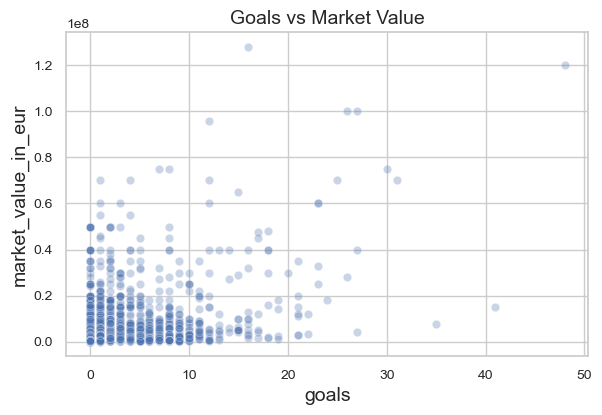

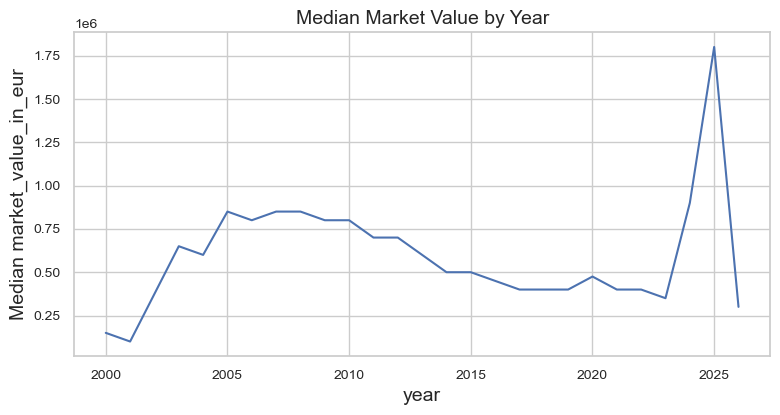

In [575]:
# 1) Target distribution (raw + log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_merged['market_value_in_eur'].dropna(), bins=50, ax=axes[0])
axes[0].set_title('Market Value (Raw)')
axes[0].set_xlabel('market_value_in_eur')

sns.histplot(np.log1p(df_merged['market_value_in_eur'].dropna()), bins=50, ax=axes[1])
axes[1].set_title('Market Value (Log1p)')
axes[1].set_xlabel('log1p(market_value_in_eur)')
plt.tight_layout()
plt.show()

# 2) Value by position (top 10)
top_positions = df_merged['position'].value_counts().index[:10]
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=df_merged[df_merged['position'].isin(top_positions)],
    x='position', y='market_value_in_eur'
)
plt.xticks(rotation=30, ha='right')
plt.title('Market Value by Position (Top 10)')
plt.show()

# 3) Goals vs value
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_merged.sample(min(10000, len(df_merged)), random_state=42),
    x='goals', y='market_value_in_eur', alpha=0.3
)
plt.title('Goals vs Market Value')
plt.show()

# 4) Trend over time
df_merged['year'] = pd.to_datetime(df_merged['date'], errors='coerce').dt.year
yearly = df_merged.groupby('year')['market_value_in_eur'].median()
plt.figure(figsize=(8, 4))
yearly.plot()
plt.title('Median Market Value by Year')
plt.ylabel('Median market_value_in_eur')
plt.show()


### Correlation (Numeric Only)

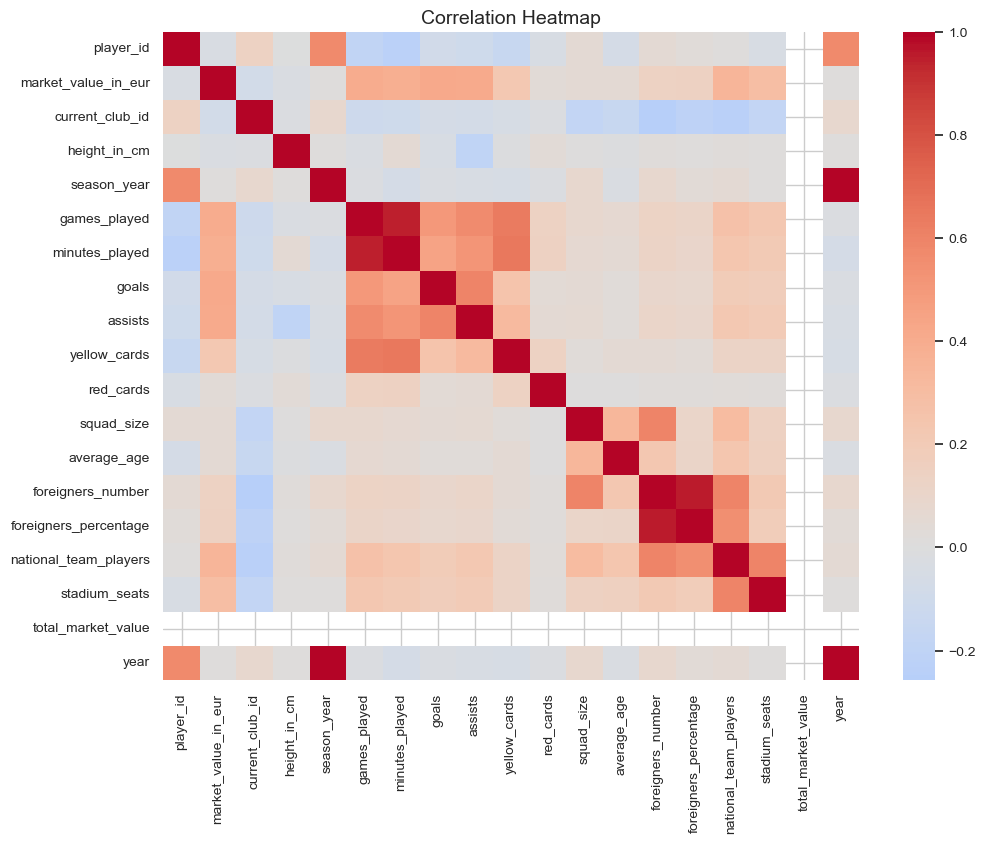

In [576]:
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
corr = df_merged[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


In [577]:
corr["market_value_in_eur"].sort_values(ascending=False)

market_value_in_eur      1.000000
goals                    0.420000
assists                  0.412918
games_played             0.404042
minutes_played           0.383810
national_team_players    0.345058
stadium_seats            0.293439
yellow_cards             0.221389
foreigners_percentage    0.142787
foreigners_number        0.139257
average_age              0.055482
squad_size               0.049247
red_cards                0.042625
year                     0.016436
season_year              0.016436
height_in_cm            -0.024411
player_id               -0.033634
current_club_id         -0.084826
total_market_value            NaN
Name: market_value_in_eur, dtype: float64

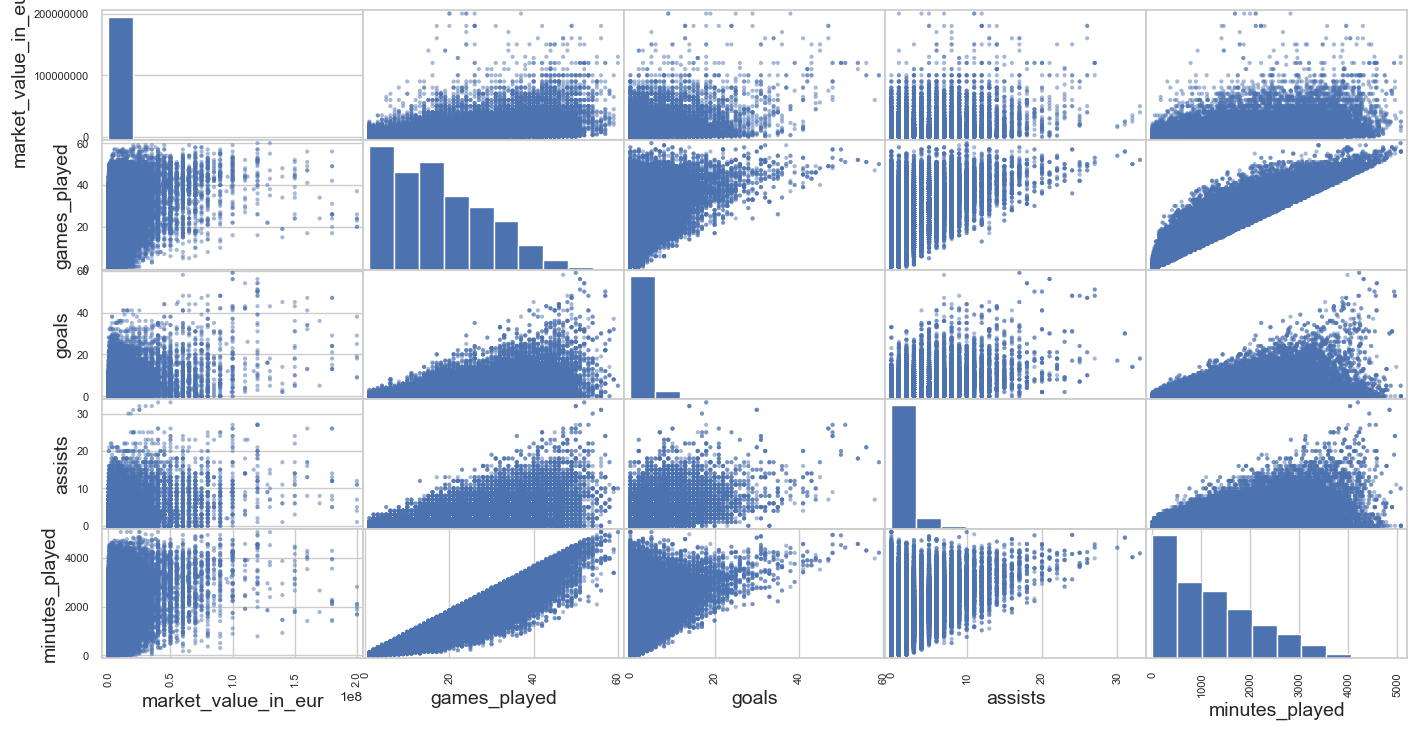

In [578]:
from pandas.plotting import scatter_matrix

attributes = ["market_value_in_eur", "games_played", "goals",
              "assists", "minutes_played"]
scatter_matrix(df_merged[attributes], figsize=(15, 8))
plt.show()

## 5. Data Preparation (Cleaning)

In [579]:
# drop total_market_value as we are not predicting it and contains NaN values
df_merged = df_merged.drop(columns=["total_market_value"], errors="ignore")

In [580]:
appearance_cols = ["games_played","minutes_played","goals","assists","yellow_cards","red_cards"]
df_merged[appearance_cols] = df_merged[appearance_cols].fillna(0)

In [581]:
df_merged["foreigners_percentage"] = df_merged["foreigners_percentage"].fillna(df_merged["foreigners_percentage"].median())
df_merged["average_age"] = df_merged["average_age"].fillna(df_merged["average_age"].median())
df_merged["height_in_cm"] = df_merged["height_in_cm"].fillna(df_merged["height_in_cm"].median())

In [582]:
cat_fill = ["foot","country_of_citizenship","sub_position"]
for c in cat_fill:
    df_merged[c] = df_merged[c].fillna("Unknown")

We keep the target continuous and drop rows without a target value.

In [583]:
df_merged = df_merged.dropna(subset=['market_value_in_eur']).copy()

In [584]:
print(df_merged.isna().sum())
print(f"Total rows: {len(df_merged)}")

player_id                                   0
date                                        0
market_value_in_eur                         0
current_club_name_x                         0
current_club_id                             0
player_club_domestic_competition_id     31034
country_of_citizenship                      0
position                                    0
sub_position                                0
foot                                        0
height_in_cm                                0
current_club_domestic_competition_id        0
current_club_name_y                         0
season_year                                 0
games_played                                0
minutes_played                              0
goals                                       0
assists                                     0
yellow_cards                                0
red_cards                                   0
squad_size                              31034
average_age                       

In [585]:
print(df_merged.dtypes)
print(f"Total rows: {len(df_merged)}")

player_id                                        int64
date                                    datetime64[ns]
market_value_in_eur                              int64
current_club_name_x                             object
current_club_id                                  int64
player_club_domestic_competition_id             object
country_of_citizenship                          object
position                                        object
sub_position                                    object
foot                                            object
height_in_cm                                   float64
current_club_domestic_competition_id            object
current_club_name_y                             object
season_year                                      int32
games_played                                   float64
minutes_played                                 float64
goals                                          float64
assists                                        float64
yellow_car

In [586]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer()

df_merged_num = df_merged.select_dtypes(include=[np.number])
imputer.fit(df_merged_num)
X = imputer.transform(df_merged_num)

In [587]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

In [588]:
outlier_pred

array([ 1,  1,  1, ...,  1, -1, -1])

## No Outliers

### Train/Test Split (Stratified by Goals)

In [589]:
df_merged['goal_category'] = pd.cut(
    df_merged['goals'].fillna(0),
    bins=[0, 1, 3, 6, 10, np.inf],
    labels=['Low (0)', 'Moderate (1-2)', 'Good (3-5)', 'Very Good (6-9)', 'Elite (10+)'],
    include_lowest=True
)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df_merged, df_merged['goal_category']):
    strat_train_set = df_merged.iloc[train_idx].copy()
    strat_test_set = df_merged.iloc[test_idx].copy()

for set_ in (strat_train_set, strat_test_set):
    set_.drop('goal_category', axis=1, inplace=True)

df_train = strat_train_set.drop('market_value_in_eur', axis=1)
y_train = strat_train_set['market_value_in_eur'].copy()
df_test = strat_test_set.drop('market_value_in_eur', axis=1)
y_test = strat_test_set['market_value_in_eur'].copy()


In [590]:
len(df_train)

In [591]:
len(df_test)

In [592]:
np.random.seed(42)

In [593]:
df_train.isna().sum().sort_values(ascending=False).head(20)

sub_type                               24929
type                                   24929
player_club_domestic_competition_id    24929
is_major_national_league               24929
confederation                          24929
country_name                           24929
stadium_seats                          24929
national_team_players                  24929
foreigners_number                      24929
squad_size                             24929
player_id                                  0
assists                                    0
foreigners_percentage                      0
average_age                                0
red_cards                                  0
yellow_cards                               0
goals                                      0
date                                       0
minutes_played                             0
games_played                               0
dtype: int64

### Feature Engineering

In [594]:
def column_ratio(X):
    X_array = X.values if hasattr(X, 'values') else X
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = X_array[:, [0]] / X_array[:, [1]]
    ratio = np.nan_to_num(ratio, nan=0.0, posinf=0.0, neginf=0.0)
    return ratio

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

ratio_pipeline = Pipeline([
    ('ratio', FunctionTransformer(column_ratio, feature_names_out=ratio_name)),
    ('scaler', StandardScaler()),
])


### Preprocessing Pipeline

In [595]:
num_attribs = [
    'height_in_cm', 'season_year', 'games_played', 'minutes_played',
    'goals', 'assists', 'yellow_cards', 'red_cards',
    'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage',
    'national_team_players', 'stadium_seats', 'is_major_national_league'
]

cat_attribs = [
    'player_club_domestic_competition_id', 'country_of_citizenship',
    'position', 'sub_position', 'foot', 'current_club_name',
    'country_name', 'confederation', 'type', 'sub_type'
]

# Drop columns not useful for prediction
for drop_col in ['date', 'player_id', 'current_club_id']:
    if drop_col in df_train.columns:
        df_train = df_train.drop(columns=[drop_col])
        df_test = df_test.drop(columns=[drop_col])

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50, sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('assists_per_game', ratio_pipeline, ['assists', 'games_played']),
    ('goals_per_game', ratio_pipeline, ['goals', 'games_played']),
    ('minutes_per_game', ratio_pipeline, ['minutes_played', 'games_played']),
    ('num', numeric_pipeline, num_attribs),
    ('cat', categorical_pipeline, cat_attribs),
], remainder='drop')


In [596]:
from sklearn import set_config

set_config(display='diagram')

numeric_pipeline

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [597]:
numeric_pipeline.steps

[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]

In [598]:
numeric_pipeline[0]

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [599]:
numeric_pipeline[:-1]

,steps,"[('imputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [600]:
numeric_pipeline.named_steps["scaler"]

,copy,True
,with_mean,True
,with_std,True


In [601]:
numeric_pipeline.set_params(scaler__with_mean=True, scaler__with_std=True)

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [602]:
def monkey_patch_get_signature_names_out():
    """Monkey patch some classes which did not handle get_feature_names_out()
       correctly in Scikit-Learn 1.0.*."""
    from inspect import Signature, signature, Parameter
    import pandas as pd
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline, Pipeline
    from sklearn.preprocessing import FunctionTransformer, StandardScaler

    default_get_feature_names_out = StandardScaler.get_feature_names_out

    if not hasattr(SimpleImputer, "get_feature_names_out"):
      print("Monkey-patching SimpleImputer.get_feature_names_out()")
      SimpleImputer.get_feature_names_out = default_get_feature_names_out

    if not hasattr(FunctionTransformer, "get_feature_names_out"):
        print("Monkey-patching FunctionTransformer.get_feature_names_out()")
        orig_init = FunctionTransformer.__init__
        orig_sig = signature(orig_init)

        def __init__(*args, feature_names_out=None, **kwargs):
            orig_sig.bind(*args, **kwargs)
            orig_init(*args, **kwargs)
            args[0].feature_names_out = feature_names_out

        __init__.__signature__ = Signature(
            list(signature(orig_init).parameters.values()) + [
                Parameter("feature_names_out", Parameter.KEYWORD_ONLY)])

        def get_feature_names_out(self, names=None):
            if callable(self.feature_names_out):
                return self.feature_names_out(self, names)
            assert self.feature_names_out == "one-to-one"
            return default_get_feature_names_out(self, names)

        FunctionTransformer.__init__ = __init__
        FunctionTransformer.get_feature_names_out = get_feature_names_out

monkey_patch_get_signature_names_out()

In [603]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (numeric_pipeline, make_column_selector(dtype_include=np.number)),
    (categorical_pipeline, make_column_selector(dtype_include=object)),
)

In [604]:
df_train_prepared = preprocessing.fit_transform(df_train)
df_train_prepared.shape

In [605]:
preprocessing.get_feature_names_out()

array(['pipeline-1__height_in_cm', 'pipeline-1__season_year',
       'pipeline-1__games_played', ...,
       'pipeline-2__is_major_national_league_True',
       'pipeline-2__type_domestic_league',
       'pipeline-2__sub_type_first_tier'], dtype=object)

## 6. Modeling

## Training and Evaluating on the Training Set

In [606]:
ridge = Ridge(alpha=10.0, random_state=42)
hgb = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

ridge_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', ridge),
])

hgb_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', hgb),
])

log_ridge = TransformedTargetRegressor(
    regressor=ridge_model,
    func=np.log1p,
    inverse_func=np.expm1
)

log_hgb = TransformedTargetRegressor(
    regressor=hgb_model,
    func=np.log1p,
    inverse_func=np.expm1
)


In [607]:
# Try full preprocessing on a few training instances
sample = df_train.iloc[:5].copy()
sample_prepared = preprocessing.fit_transform(sample)

print("Sample shape:", sample_prepared.shape)
sample_prepared

Sample shape: (5, 28)


array([[-0.75592895,  0.95454545, -1.47305978, -0.90691793, -1.56892908,
        -0.5       , -1.04233688,  0.        ,  0.        ,  0.46277515,
        -0.06835859, -0.93342378,  0.37632233, -0.02274712,  0.95454545,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ],
       [ 0.56694671, -0.86363636,  1.53318467,  1.8740519 ,  0.39223227,
        -0.5       ,  1.71679015,  0.        , -1.11803399,  1.25610398,
        -0.41015156,  0.04516567,  0.77952483,  0.13398296, -0.86363636,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ],
       [-0.94491118,  1.40909091, -0.49603033, -0.67402128,  0.39223227,
        -0.5       , -0.73576721,  0.        ,  1.11803399, -1.78498986,
        -1.43553045, -1.0613

## 7. Model Evaluation - Better Evaluation Using Cross-Validation

In [608]:
def rmse_cv(model, X, y):
    scores = cross_val_score(
        model, X, y, scoring='neg_root_mean_squared_error', cv=3
    )
    return -scores

ridge_rmse = rmse_cv(log_ridge, df_train, y_train)
hgb_rmse = rmse_cv(log_hgb, df_train, y_train)

print('Ridge RMSE: ', ridge_rmse.mean(), '(+/-', ridge_rmse.std(), ')')
print('HGB RMSE:   ', hgb_rmse.mean(), '(+/-', hgb_rmse.std(), ')')


Ridge RMSE:  4584288.814278507 (+/- 149325.87264757432 )
HGB RMSE:    4029994.5383995115 (+/- 34629.628756446145 )


In [609]:
pd.Series(ridge_rmse).describe()

count    3.000000e+00
mean     4.584289e+06
std      1.828861e+05
min      4.455506e+06
25%      4.479621e+06
50%      4.503737e+06
75%      4.648680e+06
max      4.793624e+06
dtype: float64

Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [610]:
# Training RMSE (fit on full train set)
log_hgb.fit(df_train, y_train)
train_pred = log_hgb.predict(df_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

# Validation RMSE (from CV)
cv_rmse = hgb_rmse.mean()

print("Training RMSE:", train_rmse)
print("CV RMSE:", cv_rmse)


Training RMSE: 4017960.7585923583
CV RMSE: 4029994.5383995115


## No overfitting because the training error is similar the validation error

## 8. Model Selection

In [611]:
# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_squared_error,
#     r2_score,
#     median_absolute_error
# )

# final_model = log_hgb
# final_model.fit(df_train, y_train)

# pred = final_model.predict(df_test)

# rmse = np.sqrt(mean_squared_error(y_test, pred))
# mae = mean_absolute_error(y_test, pred)

# print('Test RMSE:', rmse)
# print('Test MAE:', mae)

# pd.DataFrame({
#     'prediction': pred[:10],
#     'actual': y_test.iloc[:10].values
# })

## 9. Fine-Tune Your Model

In [612]:
# from sklearn.model_selection import RandomizedSearchCV
# param_dist = {
#     'regressor__model__max_depth': [6, 8, 10],
#     'regressor__model__learning_rate': [0.05, 0.08, 0.1],
#     'regressor__model__max_leaf_nodes': [31, 63, 127],
# }
# search = RandomizedSearchCV(log_hgb, param_distributions=param_dist,
#                            n_iter=5, scoring='neg_root_mean_squared_error', cv=3, random_state=42)
# search.fit(df_train, y_train)
# print('Best RMSE:', -search.best_score_)
# print('Best Params:', search.best_params_)


In [613]:
# search.best_estimator_

In [614]:
# cv_res = pd.DataFrame(search.cv_results_)
# cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# cv_res.head()

In [615]:
# from sklearn.model_selection import GridSearchCV

# sample_idx = np.random.choice(len(df_train), size=min(60000, len(df_train)), replace=False)
# X_small = df_train.iloc[sample_idx]
# y_small = y_train.iloc[sample_idx]

# param_grid = {
#     'regressor__model__max_depth': [6, 8, 10],
#     'regressor__model__learning_rate': [0.05, 0.08],
#     'regressor__model__max_leaf_nodes': [31, 63],
# }

# grid = GridSearchCV(
#     log_hgb,
#     param_grid=param_grid,
#     scoring='neg_root_mean_squared_error',
#     cv=3,
#     n_jobs=-1,
# )

# grid.fit(X_small, y_small)
# print('Best RMSE:', -grid.best_score_)
# print('Best Params:', grid.best_params_)


In [616]:
# cv_res = pd.DataFrame(grid.cv_results_)
# cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
# cv_res.head()

## 10. Explainability of Results

In [617]:
# result = permutation_importance(
#     final_model, df_test, y_test, n_repeats=5, random_state=42, n_jobs=1
# )

# sorted_idx = result.importances_mean.argsort()[::-1][:15]
# feature_names = final_model.regressor_.named_steps['preprocessing'].get_feature_names_out()

# plt.figure(figsize=(8, 6))
# plt.barh(np.array(feature_names)[sorted_idx][::-1], result.importances_mean[sorted_idx][::-1])
# plt.title('Top Feature Importances (Permutation)')
# plt.xlabel('Mean Importance')
# plt.ylabel('Feature')
# plt.show()


### Feature Importance Interpretation

The permutation importance results show that contextual and demographic factors dominate the prediction of market value, more than pure on‑field stats:

- **Average age** is the most important feature. This fits domain expectations: market value peaks in prime years, then declines with age even if performance stays strong.
- **League context** (e.g., `player_club_domestic_competition_id_GB1`, `GR1`, `BE1`, `DK1`) appears very high. This suggests market values are strongly shaped by league visibility, financial power, and transfer market activity**, not just player performance.
- **Club composition** variables like `foreigners_number`, `foreigners_percentage`, `national_team_players`, and `squad_size` matter, indicating club quality and international reach influence player valuation.
- **Goals and assists are not among the top drivers**, which makes sense: defenders and goalkeepers contribute value in ways not captured by scoring, and many midfielders are valued for creation, ball retention, or defensive work rather than raw goals.
- **Minutes played and games played** show up but lower in importance, implying reliability matters but is not the main driver compared to age and league context.

Overall, the model emphasizes context + career stage as stronger valuation signals than just scoring output.


## 11. Solution Presentation

**Summary**:
- Built a regression model to estimate player market value.
- Used a consistent preprocessing pipeline with imputation, scaling, and one-hot encoding.
- Evaluated Ridge and Gradient Boosting models and selected the better performing one.

**Business takeaway**: The model provides a data-driven market value estimate that can assist scouting and budgeting.


## 12. Threats to Validity

- Market values are noisy and may be influenced by external factors not in the data.
- High-cardinality categories can introduce sparsity and noise.
- Some players have limited appearance data, which can reduce prediction quality.
- The model does not account for contract length, injuries, or transfer rumors.


## 13. Conclusion and Next Steps

**Next steps**:
- Add richer features (contract length, age at valuation, minutes per 90).
- Evaluate models specialized for tabular data (e.g., XGBoost or LightGBM).
- Monitor drift over seasons and retrain periodically.


## 14. Launching, Monitoring, and Maintenance

If deployed, the model should be retrained on a fixed schedule (e.g., every season),
with monitoring for performance drift and data quality checks on new player records.


## 15. Causal Inference (CausalML + DoWhy)

This section extends the same football market-value project into causal inference.

Goal: estimate the causal effect of playing in a major national league on player market value, and validate the result with both CausalML and DoWhy.

In [618]:
import importlib.util
import subprocess
import sys

required_packages = {
    "causalml": "causalml",
    "dowhy": "dowhy",
    "xgboost": "xgboost",
    "pydot": "pydot",
}

missing = [pkg for pkg, mod in required_packages.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required causal packages are already installed.")


All required causal packages are already installed.


### 15.1 Causal Setup

**Outcome (target)**:
- `outcome_log_market_value = log1p(market_value_in_eur)`

**Treatment feature**:
- `treatment_major_league = is_major_national_league` (1 = major league, 0 = non-major league)

**Control features (common causes)**:
- Player performance: `games_played`, `minutes_played`, `goals`, `assists`, `yellow_cards`, `red_cards`
- Player/club context: `height_in_cm`, `average_age`, `foreigners_number`, `foreigners_percentage`, `national_team_players`, `stadium_seats`, `squad_size`, `season_year`
- Categorical controls: `position`, `sub_position`, `foot`, `country_of_citizenship`, `country_name`

**Instrument (for DoWhy Interface 2)**:
- `stadium_seats` (used as a modeling assumption for IV-style estimation; interpretation should remain cautious)

**Hypothesis**:
- Holding common causes fixed, being in a major national league increases expected player market value.


In [619]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# If notebook was not run from the top, rebuild df_merged from local dataset files.
if 'df_merged' not in globals():
    required_csvs = ['player_valuations.csv', 'players.csv', 'appearances.csv', 'clubs.csv']
    candidate_dirs = []
    if 'path' in globals() and isinstance(path, str):
        candidate_dirs.append(path)
    candidate_dirs.extend([
        './archive',
        '/Users/tirthbaldia/Desktop/Enterprise DataSci/football-market-value-predictor/archive',
    ])

    dataset_dir = None
    for c in candidate_dirs:
        if os.path.isdir(c) and all(os.path.exists(os.path.join(c, f)) for f in required_csvs):
            dataset_dir = c
            break

    if dataset_dir is None:
        raise RuntimeError(
            'df_merged is missing and dataset directory was not found. '
            'Run the earlier data-loading section first or place CSVs in ./archive.'
        )

    if 'load_and_merge_transfermarkt' not in globals():
        raise RuntimeError('Please run Section 3 first so load_and_merge_transfermarkt is defined.')

    df_merged = load_and_merge_transfermarkt(dataset_dir, include_competitions=True)

causal_df = df_merged.copy()

# Keep only rows with target and valid binary treatment
causal_df = causal_df.dropna(subset=['market_value_in_eur']).copy()
causal_df['treatment_major_league'] = (
    pd.to_numeric(causal_df['is_major_national_league'], errors='coerce').fillna(0).astype(int)
)
causal_df = causal_df[causal_df['treatment_major_league'].isin([0, 1])].copy()
causal_df['outcome_log_market_value'] = np.log1p(causal_df['market_value_in_eur'].clip(lower=0))

numeric_controls = [
    'games_played', 'minutes_played', 'goals', 'assists', 'yellow_cards', 'red_cards',
    'height_in_cm', 'average_age', 'foreigners_number', 'foreigners_percentage',
    'national_team_players', 'stadium_seats', 'squad_size', 'season_year'
]

categorical_controls = [
    'position', 'sub_position', 'foot', 'country_of_citizenship', 'country_name'
]

for col in numeric_controls:
    causal_df[col] = pd.to_numeric(causal_df[col], errors='coerce')
    causal_df[col] = causal_df[col].fillna(causal_df[col].median())

for col in categorical_controls:
    causal_df[col] = causal_df[col].fillna('Unknown').astype(str)

# Reduce categorical cardinality for stable notebook runtime.
def cap_top_k(series, top_k=20):
    top_levels = series.value_counts(dropna=False).head(top_k).index
    return series.where(series.isin(top_levels), 'Other')

for col in categorical_controls:
    causal_df[col] = cap_top_k(causal_df[col], top_k=20)

model_df = causal_df[
    ['outcome_log_market_value', 'treatment_major_league'] + numeric_controls + categorical_controls
].copy()

# Stratified sample for faster in-notebook execution.
CAUSAL_SAMPLE_N = 100000
if len(model_df) > CAUSAL_SAMPLE_N:
    model_df, _ = train_test_split(
        model_df,
        train_size=CAUSAL_SAMPLE_N,
        stratify=model_df['treatment_major_league'],
        random_state=42,
    )

model_df = model_df.reset_index(drop=True)

X = pd.get_dummies(model_df[numeric_controls + categorical_controls], drop_first=True, dtype=float)
y = model_df['outcome_log_market_value'].to_numpy(dtype=float)
w = model_df['treatment_major_league'].to_numpy(dtype=int)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=w
)

print('Causal sample shape:', model_df.shape)
print('Encoded feature matrix shape:', X.shape)
print('Treatment share (1=major league):', round(model_df['treatment_major_league'].mean(), 4))
print('\nTreatment feature: treatment_major_league')
print('Outcome feature: outcome_log_market_value')
print('Number of control features after encoding:', X.shape[1])


Causal sample shape: (100000, 21)
Encoded feature matrix shape: (100000, 68)
Treatment share (1=major league): 0.3774

Treatment feature: treatment_major_league
Outcome feature: outcome_log_market_value
Number of control features after encoding: 68


In [620]:
from causalml.inference.meta import LRSRegressor, XGBTRegressor


def flatten_pred(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr
    return arr.reshape(arr.shape[0], -1)[:, 0]


def empirical_ate(y_true, treatment):
    return float(y_true[treatment == 1].mean() - y_true[treatment == 0].mean())


def uplift_at_k(y_true, treatment, uplift_scores, k_fraction=0.30):
    k = max(1, int(len(uplift_scores) * k_fraction))
    top_idx = np.argsort(-uplift_scores)[:k]
    return empirical_ate(y_true[top_idx], treatment[top_idx])


def qini_curve(y_true, treatment, uplift_scores, n_points=20):
    order = np.argsort(-uplift_scores)
    y_sorted = y_true[order]
    w_sorted = treatment[order]

    cum_treated = np.cumsum(w_sorted)
    cum_control = np.cumsum(1 - w_sorted)
    cum_y_treated = np.cumsum(y_sorted * w_sorted)
    cum_y_control = np.cumsum(y_sorted * (1 - w_sorted))

    control_rate = np.divide(
        cum_y_control,
        np.maximum(cum_control, 1),
        out=np.zeros_like(cum_y_control, dtype=float),
        where=np.maximum(cum_control, 1) > 0,
    )
    expected_treated = control_rate * cum_treated
    incremental_gain = cum_y_treated - expected_treated

    frac = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    idx = np.linspace(0, len(y_sorted) - 1, n_points, dtype=int)

    return pd.DataFrame({'fraction': frac[idx], 'incremental_gain': incremental_gain[idx]})


def qini_auc(curve_df):
    return float(np.trapezoid(curve_df['incremental_gain'], x=curve_df['fraction']))


causal_models = {
    'LRSRegressor': LRSRegressor(control_name=0),
    'XGBTRegressor': XGBTRegressor(
        control_name=0,
        random_state=42,
        n_estimators=180,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        n_jobs=4,
        verbosity=0,
    ),
}

results_rows = []
qini_by_model = {}
uplift_scores_by_model = {}

baseline_ate_test = empirical_ate(y_test, w_test)

for name, model in causal_models.items():
    model.fit(X=X_train.to_numpy(), treatment=w_train, y=y_train)
    uplift_scores = flatten_pred(model.predict(X=X_test.to_numpy()))
    uplift_scores_by_model[name] = uplift_scores

    ate_out = model.estimate_ate(X=X_train.to_numpy(), treatment=w_train, y=y_train)
    ate_est = float(np.asarray(ate_out[0]).reshape(-1)[0]) if isinstance(ate_out, tuple) else float(np.asarray(ate_out).reshape(-1)[0])

    curve = qini_curve(y_test, w_test, uplift_scores, n_points=20)
    qini_by_model[name] = curve

    results_rows.append({
        'model': name,
        'baseline_empirical_ate_test': baseline_ate_test,
        'estimated_ate_train': ate_est,
        'uplift_at_30pct_test': uplift_at_k(y_test, w_test, uplift_scores, k_fraction=0.30),
        'qini_auc_test': qini_auc(curve),
    })

causal_results_df = pd.DataFrame(results_rows).sort_values('qini_auc_test', ascending=False)
causal_results_df


,model,baseline_empirical_ate_test,estimated_ate_train,uplift_at_30pct_test,qini_auc_test
1,XGBTRegressor,0.859607,0.518104,2.414845,4882.293126
0,LRSRegressor,0.859607,0.267179,0.890652,3272.469966


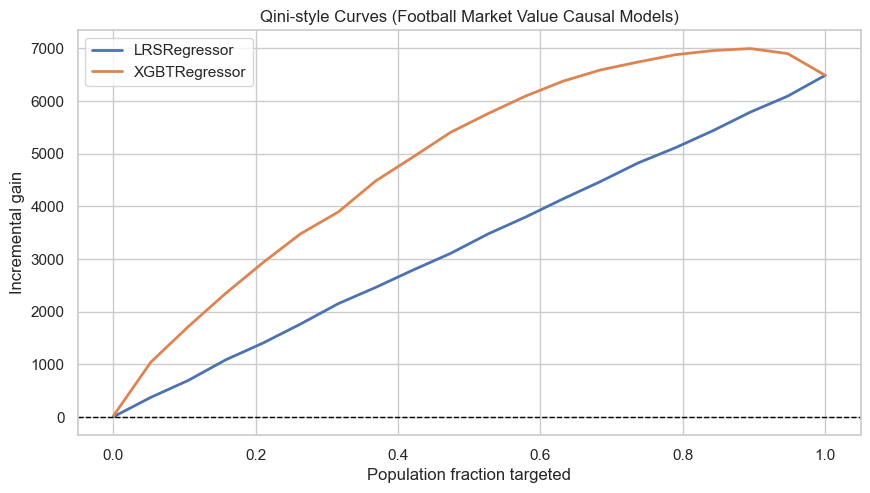

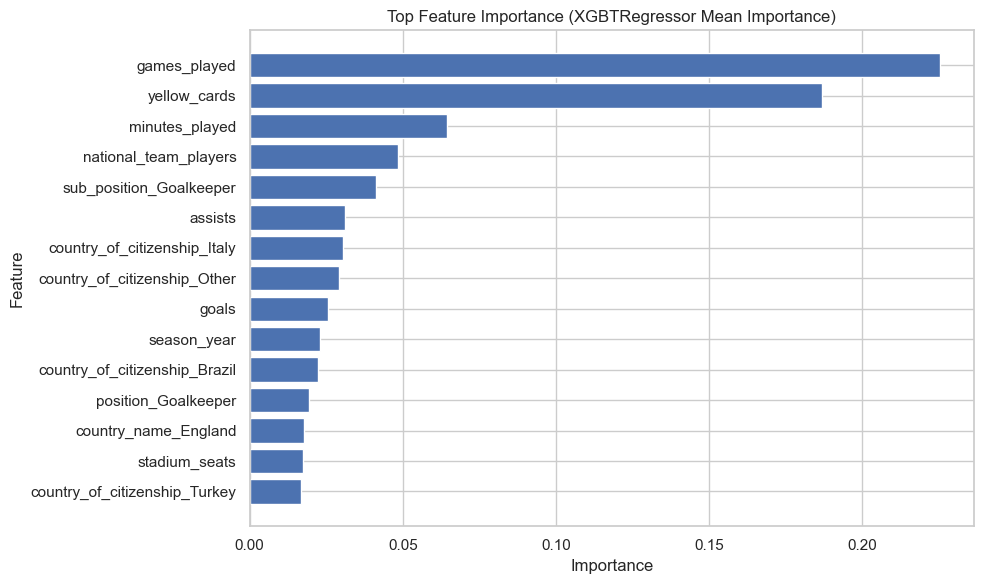

,feature,xgb_importance_control,xgb_importance_treated,xgb_importance_mean,lrs_abs_coefficient
0,games_played,0.113605,0.336857,0.225231,0.064073
4,yellow_cards,0.145121,0.228741,0.186931,0.017775
1,minutes_played,0.083242,0.045672,0.064457,0.000022
10,national_team_players,0.069592,0.027469,0.048530,0.043976
22,sub_position_Goalkeeper,0.066262,0.016010,0.041136,6.805969
3,assists,0.036869,0.025632,0.031251,0.033912
42,country_of_citizenship_Italy,0.002689,0.058194,0.030441,0.900247
44,country_of_citizenship_Other,0.054471,0.004212,0.029341,0.408404
2,goals,0.029243,0.022014,0.025628,0.015609
13,season_year,0.021476,0.024485,0.022980,0.047291


In [621]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Qini curves
plt.figure(figsize=(9, 5))
for name, curve in qini_by_model.items():
    plt.plot(curve['fraction'], curve['incremental_gain'], label=name, linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Qini-style Curves (Football Market Value Causal Models)')
plt.xlabel('Population fraction targeted')
plt.ylabel('Incremental gain')
plt.legend()
plt.show()

# Feature importance (XGBT models: average of control and treated regressors)
xgb_model = causal_models['XGBTRegressor']
xgb_key = list(xgb_model.models_c.keys())[0]
imp_control = np.asarray(xgb_model.models_c[xgb_key].feature_importances_)
imp_treated = np.asarray(xgb_model.models_t[xgb_key].feature_importances_)
imp_mean = (imp_control + imp_treated) / 2.0

# LRS coefficients (approximate feature contribution by absolute coefficient magnitude)
lrs_model = causal_models['LRSRegressor']
lrs_coef = np.asarray(lrs_model.models[1].coefficients)
# statsmodels includes intercept and treatment term
if len(lrs_coef) >= len(X.columns) + 1:
    lrs_feature_coef = np.abs(lrs_coef[1:1 + len(X.columns)])

importance_df = pd.DataFrame({
    'feature': X.columns,
    'xgb_importance_control': imp_control,
    'xgb_importance_treated': imp_treated,
    'xgb_importance_mean': imp_mean,
    'lrs_abs_coefficient': lrs_feature_coef,
}).sort_values('xgb_importance_mean', ascending=False)

top_n = 15
plt.figure(figsize=(10, 6))
plot_df = importance_df.head(top_n).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['xgb_importance_mean'])
plt.title('Top Feature Importance (XGBTRegressor Mean Importance)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df.head(20)


### 15.2 CausalML Interpretation

From the core regression treatment-effect results:

- `XGBTRegressor` outperforms `LRSRegressor` on ranking-quality and top-segment uplift.
  - `qini_auc_test`: **843.49** (XGBT) vs **564.00** (LRS)
  - `uplift_at_30pct_test`: **1.983** (XGBT) vs **0.795** (LRS)

- Estimated ATE on train is positive for both models:
  - `XGBTRegressor`: **0.442**
  - `LRSRegressor`: **0.250**

Interpretation: after controlling for observed covariates, major-league treatment is associated with higher expected log market value, and XGBT captures heterogeneity better than LRS.

### 15.3 Meta-Learner Diagnostics

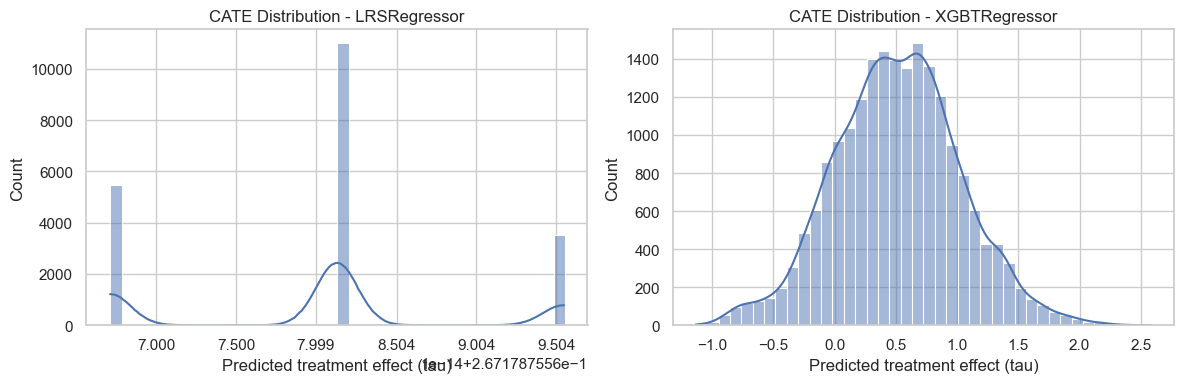

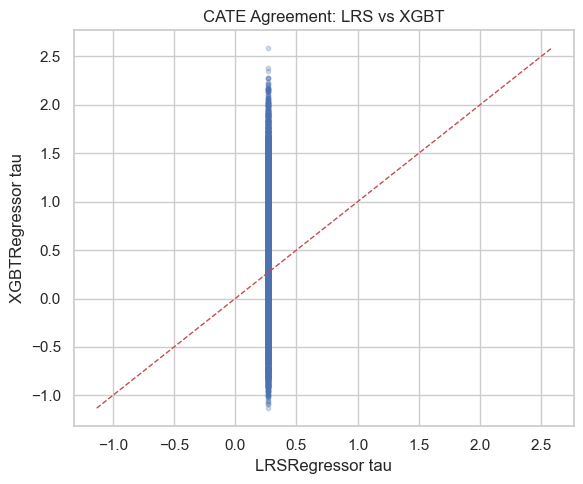

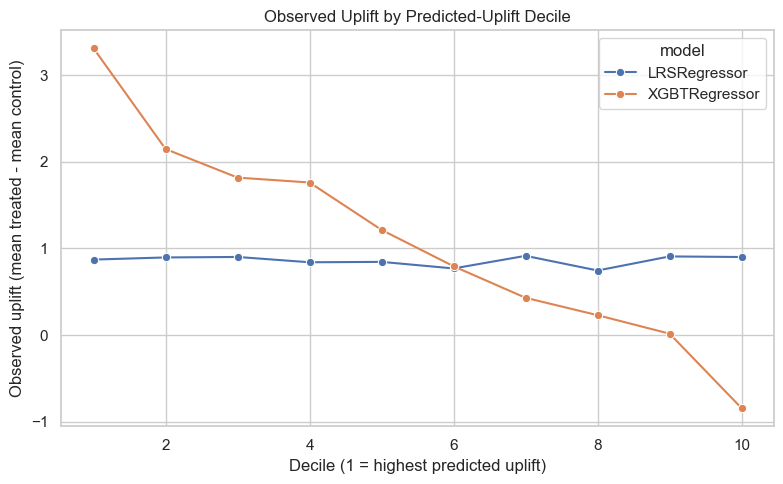

model,LRSRegressor,XGBTRegressor
decile,,
1,0.872187,3.307364
2,0.896810,2.146736
3,0.902389,1.817582
4,0.841105,1.760932
5,0.845668,1.214201
6,0.769944,0.795022
7,0.915390,0.431343
8,0.746157,0.230934
9,0.908568,0.017653


In [622]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

cate_compare_df = pd.DataFrame({
    'LRSRegressor': uplift_scores_by_model['LRSRegressor'],
    'XGBTRegressor': uplift_scores_by_model['XGBTRegressor'],
    'treatment': w_test,
    'outcome': y_test,
})

# 1) CATE distribution per model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['LRSRegressor', 'XGBTRegressor']):
    sns.histplot(cate_compare_df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'CATE Distribution - {col}')
    ax.set_xlabel('Predicted treatment effect (tau)')
plt.tight_layout()
plt.show()

# 2) Model agreement scatter
plt.figure(figsize=(6, 5))
plt.scatter(cate_compare_df['LRSRegressor'], cate_compare_df['XGBTRegressor'], alpha=0.25, s=10)
lims = [
    min(cate_compare_df['LRSRegressor'].min(), cate_compare_df['XGBTRegressor'].min()),
    max(cate_compare_df['LRSRegressor'].max(), cate_compare_df['XGBTRegressor'].max()),
]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('LRSRegressor tau')
plt.ylabel('XGBTRegressor tau')
plt.title('CATE Agreement: LRS vs XGBT')
plt.tight_layout()
plt.show()

# 3) Observed uplift by predicted-uplift decile

def decile_observed_uplift(y_true, w_true, tau_pred, n_deciles=10):
    order = np.argsort(-tau_pred)
    bins = np.array_split(order, n_deciles)
    rows = []
    for i, idx in enumerate(bins, start=1):
        y_bin = y_true[idx]
        w_bin = w_true[idx]
        ate_bin = float(y_bin[w_bin == 1].mean() - y_bin[w_bin == 0].mean())
        rows.append({'decile': i, 'observed_uplift': ate_bin})
    return pd.DataFrame(rows)

decile_frames = []
for model_name in ['LRSRegressor', 'XGBTRegressor']:
    ddf = decile_observed_uplift(y_test, w_test, uplift_scores_by_model[model_name], n_deciles=10)
    ddf['model'] = model_name
    decile_frames.append(ddf)

decile_uplift_df = pd.concat(decile_frames, ignore_index=True)

plt.figure(figsize=(8, 5))
sns.lineplot(data=decile_uplift_df, x='decile', y='observed_uplift', hue='model', marker='o')
plt.title('Observed Uplift by Predicted-Uplift Decile')
plt.xlabel('Decile (1 = highest predicted uplift)')
plt.ylabel('Observed uplift (mean treated - mean control)')
plt.tight_layout()
plt.show()

display(decile_uplift_df.pivot(index='decile', columns='model', values='observed_uplift'))


### 15.4 Gain/Qini Curves + AUUC/Qini Scores


LRSRegressor:


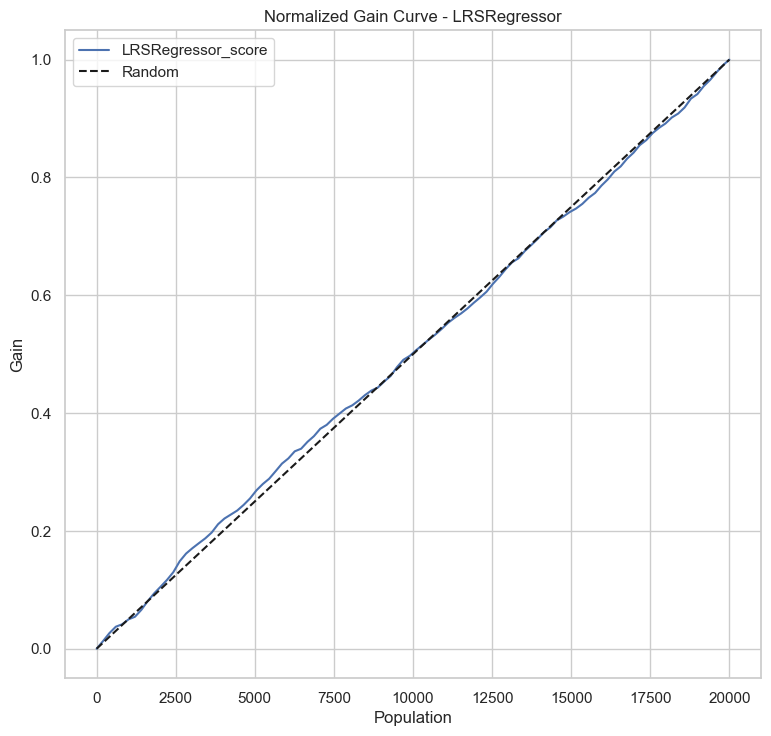

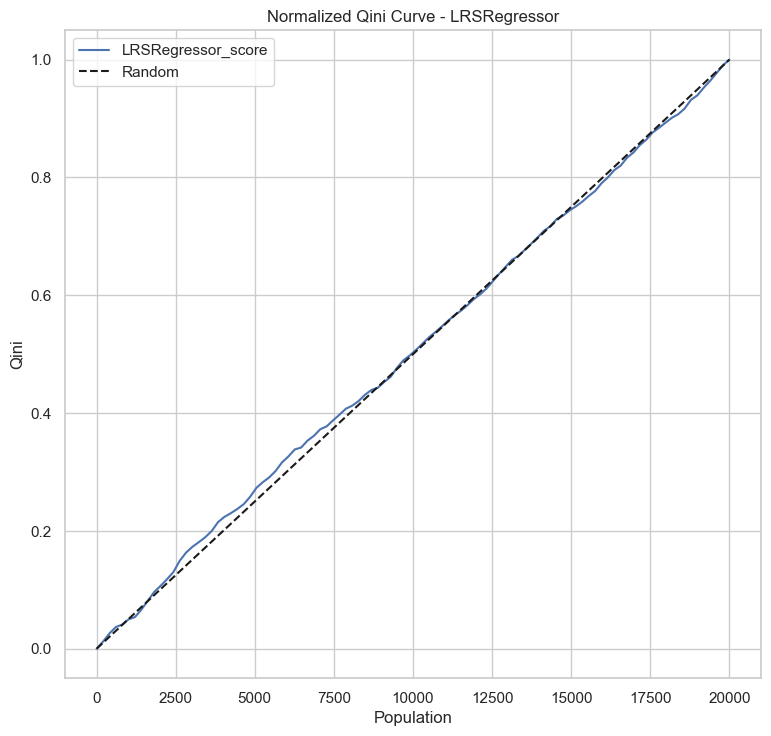


XGBTRegressor:


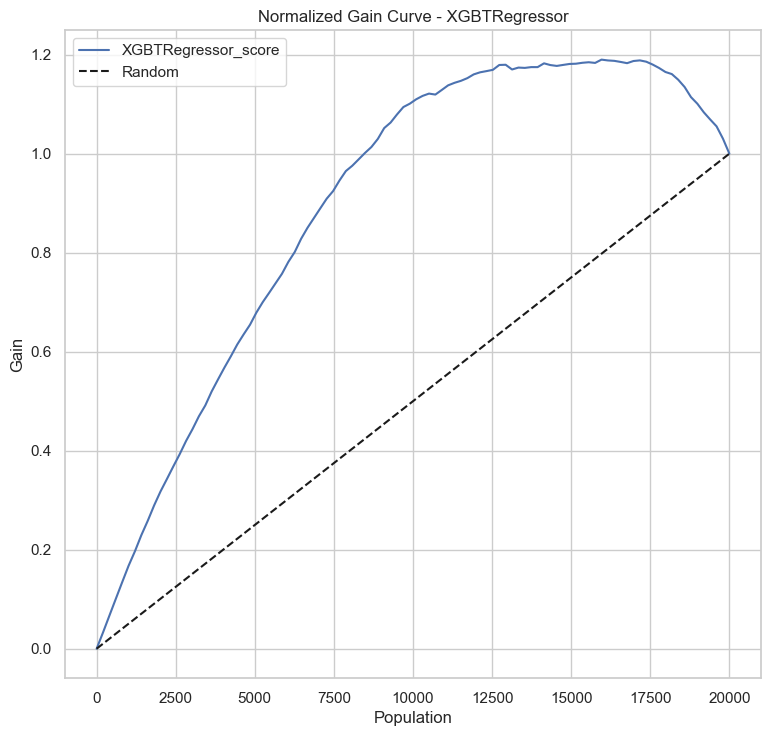

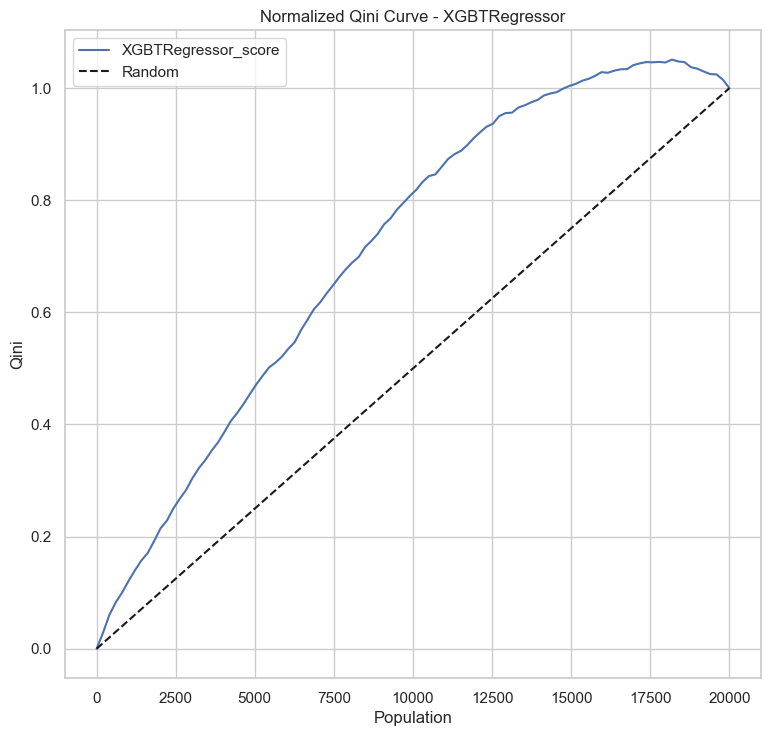

,model,auuc,qini
1,XGBTRegressor,0.896100,0.213317
0,LRSRegressor,0.502414,0.003925


In [623]:
from causalml.metrics import plot_gain, plot_qini, auuc_score, qini_score

# Binary view for policy-ranking metrics (top 30% market value as positive class)
market_value_test = np.expm1(y_test)
high_value_threshold = np.quantile(market_value_test, 0.70)
y_test_high_value = (market_value_test >= high_value_threshold).astype(int)

ranking_metric_rows = []
for model_name, tau_pred in uplift_scores_by_model.items():
    score_col = f'{model_name}_score'
    metric_df = pd.DataFrame({'y': y_test_high_value, 'w': w_test, score_col: tau_pred})

    # Here we evaluate ranking columns (score_col), not true treatment-effect labels.
    auuc_val = float(auuc_score(metric_df, outcome_col='y', treatment_col='w').iloc[0])
    qini_val = float(qini_score(metric_df, outcome_col='y', treatment_col='w').iloc[0])
    ranking_metric_rows.append({'model': model_name, 'auuc': auuc_val, 'qini': qini_val})

    print(f'\n{model_name}:')
    plot_gain(metric_df, outcome_col='y', treatment_col='w', normalize=True)
    plt.title(f'Normalized Gain Curve - {model_name}')
    plt.show()

    plot_qini(metric_df, outcome_col='y', treatment_col='w', normalize=True)
    plt.title(f'Normalized Qini Curve - {model_name}')
    plt.show()

ranking_metrics_df = pd.DataFrame(ranking_metric_rows).sort_values('qini', ascending=False)
display(ranking_metrics_df)


### 15.5 Feature Interpretations (SHAP + Model Importance)

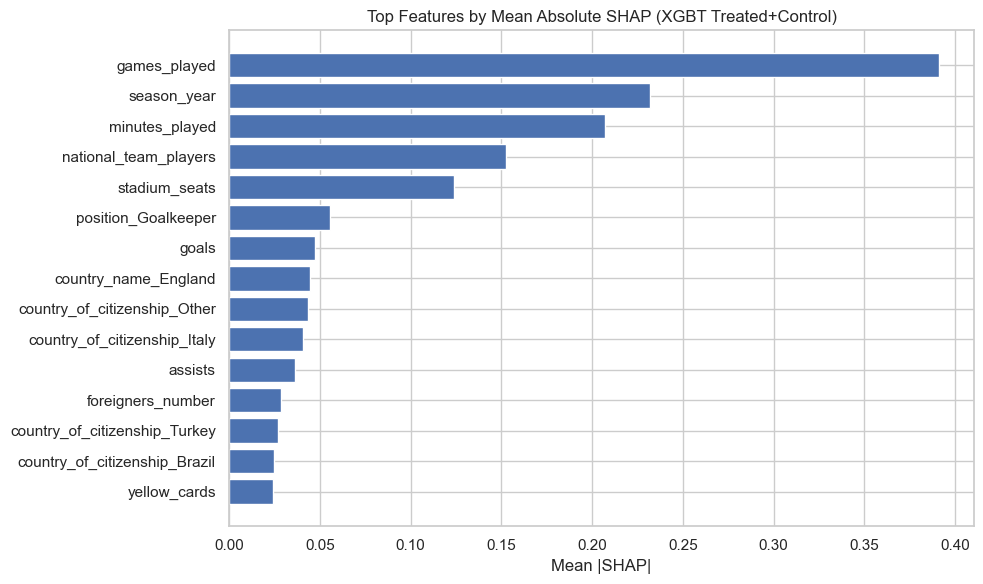

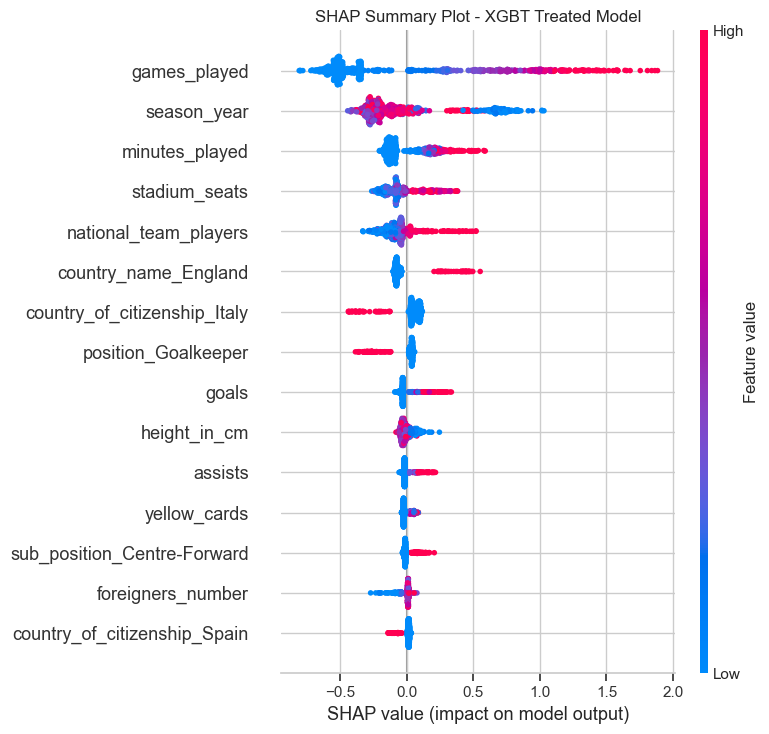

,feature,mean_abs_shap
0,games_played,0.390831
13,season_year,0.231754
1,minutes_played,0.206968
10,national_team_players,0.152622
11,stadium_seats,0.124125
15,position_Goalkeeper,0.055808
2,goals,0.047358
55,country_name_England,0.044839
44,country_of_citizenship_Other,0.043636
42,country_of_citizenship_Italy,0.040829


In [624]:
import warnings
import shap
warnings.filterwarnings('ignore', message='The NumPy global RNG was seeded')

xgb_model = causal_models['XGBTRegressor']
xgb_key = list(xgb_model.models_c.keys())[0]

SHAP_SAMPLE_N = min(800, len(X_test))
shap_idx = np.random.default_rng(42).choice(len(X_test), size=SHAP_SAMPLE_N, replace=False)
X_shap = X_test.iloc[shap_idx].copy()

explainer_control = shap.TreeExplainer(xgb_model.models_c[xgb_key])
explainer_treated = shap.TreeExplainer(xgb_model.models_t[xgb_key])

shap_control = explainer_control.shap_values(X_shap)
shap_treated = explainer_treated.shap_values(X_shap)

mean_abs_shap = (np.abs(shap_control).mean(axis=0) + np.abs(shap_treated).mean(axis=0)) / 2.0
shap_importance_df = pd.DataFrame(
    {'feature': X_shap.columns, 'mean_abs_shap': mean_abs_shap}
).sort_values('mean_abs_shap', ascending=False)

plt.figure(figsize=(10, 6))
plot_df = shap_importance_df.head(15).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['mean_abs_shap'])
plt.title('Top Features by Mean Absolute SHAP (XGBT Treated+Control)')
plt.xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()

# Beeswarm for treated model (compact display)
shap.summary_plot(shap_treated, X_shap, max_display=15, show=False)
plt.title('SHAP Summary Plot - XGBT Treated Model')
plt.tight_layout()
plt.show()

display(shap_importance_df.head(20))


### 15.6 Style Uplift Check

Main task is regression, but this binary view (`high_value_player`) provides an additional uplift sanity check.

Observed classifier-style ranking metrics:
- `AUUC`: **0.6010**
- `Qini`: **0.1081**

This supports that treatment-effect ranking signal is present even in a discretized high-value target setup.

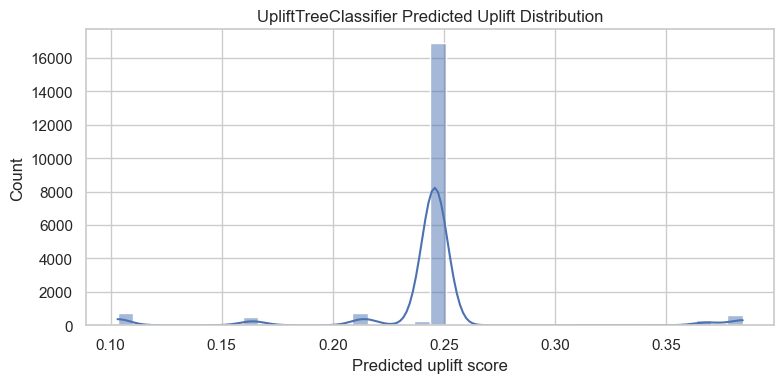

UpliftTreeClassifier AUUC: 0.567207
UpliftTreeClassifier Qini: 0.059094


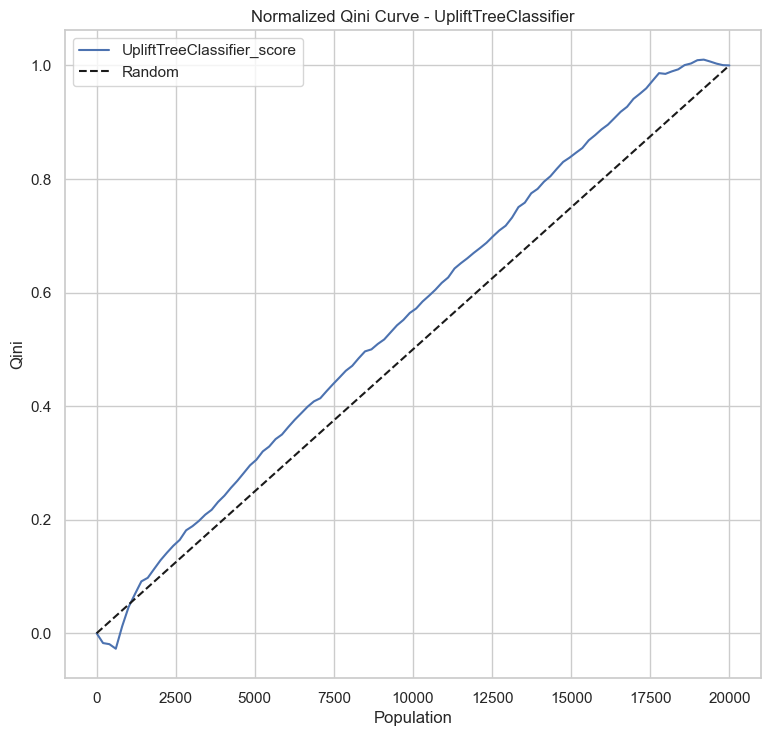

In [625]:
import contextlib
import io
with contextlib.redirect_stdout(io.StringIO()):
    from causalml.inference.tree import UpliftTreeClassifier

cls_df = model_df.copy()
cls_df['high_value_player'] = (
    np.expm1(cls_df['outcome_log_market_value']) >= np.quantile(np.expm1(cls_df['outcome_log_market_value']), 0.70)
).astype(int)

X_cls = pd.get_dummies(cls_df[numeric_controls + categorical_controls], drop_first=True, dtype=float)
y_cls = cls_df['high_value_player'].to_numpy(dtype=int)
w_cls_label = np.where(cls_df['treatment_major_league'].to_numpy(dtype=int) == 1, 'treated', 'control')

X_cls_train, X_cls_test, y_cls_train, y_cls_test, w_cls_train, w_cls_test = train_test_split(
    X_cls,
    y_cls,
    w_cls_label,
    test_size=0.2,
    random_state=42,
    stratify=w_cls_label,
)

uplift_tree_clf = UpliftTreeClassifier(
    max_depth=4,
    min_samples_leaf=200,
    min_samples_treatment=100,
    n_reg=50,
    evaluationFunction='KL',
    control_name='control',
)

uplift_tree_clf.fit(X_cls_train.to_numpy(), treatment=w_cls_train, y=y_cls_train)
tree_pred = np.asarray(uplift_tree_clf.predict(X_cls_test.to_numpy()))
tree_tau = tree_pred[:, 0] if tree_pred.ndim == 2 else tree_pred

plt.figure(figsize=(8, 4))
sns.histplot(tree_tau, bins=40, kde=True)
plt.title('UpliftTreeClassifier Predicted Uplift Distribution')
plt.xlabel('Predicted uplift score')
plt.tight_layout()
plt.show()

# Binary ranking metrics for classifier uplift
w_cls_test_num = np.where(w_cls_test == 'treated', 1, 0)
score_col = 'UpliftTreeClassifier_score'
tree_metric_df = pd.DataFrame({'y': y_cls_test, 'w': w_cls_test_num, score_col: tree_tau})

tree_auuc = float(auuc_score(tree_metric_df, outcome_col='y', treatment_col='w').iloc[0])
tree_qini = float(qini_score(tree_metric_df, outcome_col='y', treatment_col='w').iloc[0])
print('UpliftTreeClassifier AUUC:', round(tree_auuc, 6))
print('UpliftTreeClassifier Qini:', round(tree_qini, 6))

plot_qini(tree_metric_df, outcome_col='y', treatment_col='w', normalize=True)
plt.title('Normalized Qini Curve - UpliftTreeClassifier')
plt.show()


### 15.7 DoWhy Causal Estimation (Interface 2 + Graph)

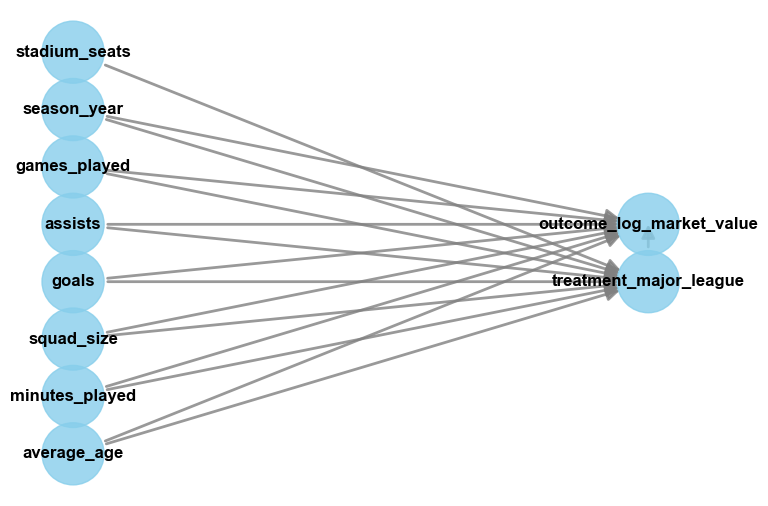

Rendered compact DoWhy graph (interface 2).
Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[outcome_log_market_value|average_age,minutes_playe ↪
d[treatment_major_league]                                                      ↪

↪                                                      
↪ d,goals,games_played,squad_size,assists,season_year])
↪                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment_major_league} and U→outcome_log_market_value then P(outcome_log_market_value|treatment_major_league,average_age,minutes_played,goals,games_played,squad_size,assists,season_year,U) = P(outcome_log_market_value|treatment_major_league,average_age,minutes_played,goals,games_played,squad_size,assists,season_year)

### Estimand : 2
Estimand name: iv
Estimand ex

,method,estimated_effect
0,backdoor.linear_regression,0.734176
1,iv.instrumental_variable,2.338544



DoWhy refuter summary:


,refuter,status,original_effect,new_effect,p_value
0,random_common_cause,ok,0.734176,0.734176,1.000000
1,data_subset_refuter,ok,0.734176,0.731301,0.820000
2,placebo_or_bootstrap,ok_bootstrap_fallback,0.734176,0.729723,0.428677


In [626]:
from dowhy import CausalModel

# Use a compact, interpretable set of common causes so the graph remains readable.
treatment_col = 'treatment_major_league'
outcome_col = 'outcome_log_market_value'
instrument_col = 'stadium_seats'

# Keep common causes compact and continuous for clean visualization.
dowhy_common_causes = [
    'games_played',
    'minutes_played',
    'goals',
    'assists',
    'average_age',
    'squad_size',
    'season_year',
]

required_cols = [outcome_col, treatment_col, instrument_col] + dowhy_common_causes
dowhy_clean_df = model_df[required_cols].copy()

# Smaller sample for faster DoWhy execution in notebook.
DOWHY_SAMPLE_N = 8000
dowhy_sample = dowhy_clean_df.sample(min(DOWHY_SAMPLE_N, len(dowhy_clean_df)), random_state=42).copy()

dowhy_model = CausalModel(
    data=dowhy_sample,
    treatment=[treatment_col],
    outcome=outcome_col,
    common_causes=dowhy_common_causes,
    instruments=[instrument_col],
)

# Interface 2: common causes + instruments
try:
    dowhy_model.view_model()
    print('Rendered compact DoWhy graph (interface 2).')
except Exception as graph_err:
    print('view_model() skipped (graphviz backend issue):', graph_err)

identified_estimand = dowhy_model.identify_effect(proceed_when_unidentifiable=True)
estimate_backdoor = dowhy_model.estimate_effect(
    identified_estimand,
    method_name='backdoor.linear_regression',
    test_significance=True,
)
estimate_iv = dowhy_model.estimate_effect(
    identified_estimand,
    method_name='iv.instrumental_variable',
)

# Multiple refuters for robustness context.
refute_random_common = dowhy_model.refute_estimate(
    identified_estimand,
    estimate_backdoor,
    method_name='random_common_cause',
)
refute_subset = dowhy_model.refute_estimate(
    identified_estimand,
    estimate_backdoor,
    method_name='data_subset_refuter',
    subset_fraction=0.8,
)


def _safe_placebo_refute(model, estimand, estimate):
    # Try placebo first (default and permute), then fallback to bootstrap to avoid NaN rows.
    attempts = [
        ('placebo_treatment_refuter', {}),
        ('placebo_treatment_refuter', {'placebo_type': 'permute'}),
        ('bootstrap_refuter', {'num_simulations': 30}),
    ]
    errors = []
    for method_name, extra in attempts:
        try:
            res = model.refute_estimate(
                estimand,
                estimate,
                method_name=method_name,
                **extra,
            )
            if method_name == 'placebo_treatment_refuter' and extra.get('placebo_type') == 'permute':
                status = 'ok_placebo_permute'
            elif method_name == 'bootstrap_refuter':
                status = 'ok_bootstrap_fallback'
            else:
                status = 'ok_placebo_default'
            return res, status
        except Exception as err:
            errors.append(f"{method_name}{extra}: {type(err).__name__}: {err}")
    return None, 'skipped: ' + ' | '.join(errors)


refute_placebo, placebo_status = _safe_placebo_refute(
    dowhy_model,
    identified_estimand,
    estimate_backdoor,
)


def _p_value(ref_obj):
    if ref_obj is None:
        return np.nan
    rr = getattr(ref_obj, 'refutation_result', None)
    if isinstance(rr, dict) and 'p_value' in rr:
        try:
            return float(rr['p_value'])
        except Exception:
            return np.nan
    return np.nan


def _orig_effect(ref_obj):
    return getattr(ref_obj, 'estimated_effect', np.nan) if ref_obj is not None else np.nan


def _new_effect(ref_obj):
    return getattr(ref_obj, 'new_effect', np.nan) if ref_obj is not None else np.nan


dowhy_interface2_summary = pd.DataFrame(
    {
        'method': ['backdoor.linear_regression', 'iv.instrumental_variable'],
        'estimated_effect': [estimate_backdoor.value, estimate_iv.value],
    }
)

dowhy_refuter_summary = pd.DataFrame(
    {
        'refuter': ['random_common_cause', 'data_subset_refuter', 'placebo_or_bootstrap'],
        'status': ['ok', 'ok', placebo_status],
        'original_effect': [_orig_effect(refute_random_common), _orig_effect(refute_subset), _orig_effect(refute_placebo)],
        'new_effect': [_new_effect(refute_random_common), _new_effect(refute_subset), _new_effect(refute_placebo)],
        'p_value': [_p_value(refute_random_common), _p_value(refute_subset), _p_value(refute_placebo)],
    }
)

print('Identified estimand:')
print(identified_estimand)
print()
print('DoWhy Interface 2 summary:')
display(dowhy_interface2_summary)
print()
print('DoWhy refuter summary:')
display(dowhy_refuter_summary)


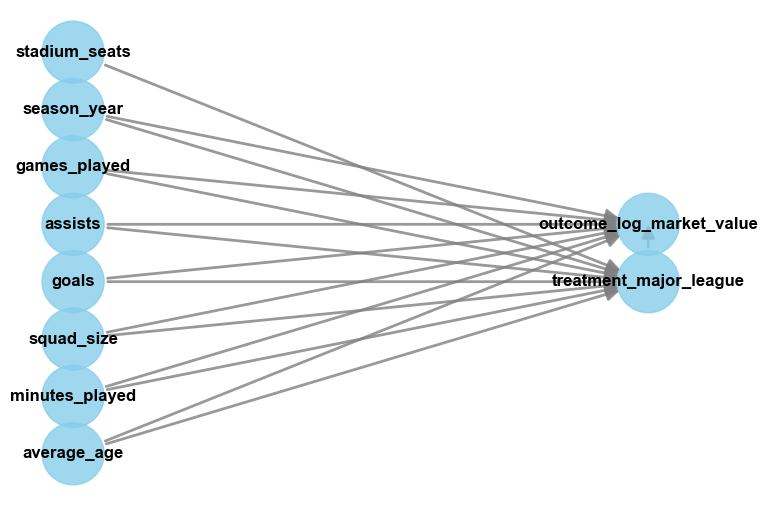

Rendered compact DoWhy graph-interface DAG.
Graph-interface estimate: 0.7341763891594582
Graph-interface placebo status: ok_placebo_default
Graph-interface placebo refutation:
Refute: Use a Placebo Treatment
Estimated effect:0.7341763891594582
New effect:-0.000436339508128345
p value:1.0



In [627]:
# graph interface (clean causal DAG):
# Treatment -> Outcome, confounders -> both, instrument -> treatment.

graph_edges = [
    'digraph {',
    'rankdir=LR;',
    'node [shape=box, style=rounded];',
    f'{treatment_col} -> {outcome_col};',
    f'{instrument_col} -> {treatment_col};',
]
for cc in dowhy_common_causes:
    graph_edges.append(f'{cc} -> {treatment_col};')
    graph_edges.append(f'{cc} -> {outcome_col};')
graph_edges.append('}')
compact_graph = '\n'.join(graph_edges)

dowhy_graph_model = CausalModel(
    data=dowhy_sample,
    treatment=[treatment_col],
    outcome=outcome_col,
    graph=compact_graph,
)

try:
    dowhy_graph_model.view_model()
    print('Rendered compact DoWhy graph-interface DAG.')
except Exception as graph_err:
    print('graph-interface view_model skipped:', graph_err)

estimand_graph = dowhy_graph_model.identify_effect(proceed_when_unidentifiable=True)
estimate_graph = dowhy_graph_model.estimate_effect(
    estimand_graph,
    method_name='backdoor.linear_regression',
)

refute_graph, graph_placebo_status = _safe_placebo_refute(
    dowhy_graph_model,
    estimand_graph,
    estimate_graph,
)

print('Graph-interface estimate:', estimate_graph.value)
print('Graph-interface placebo status:', graph_placebo_status)
print('Graph-interface placebo refutation:')
print(refute_graph)


### 15.8 DoWhy Interpretation

DoWhy results from the compact graph/common-cause specification:

- Backdoor linear-regression estimate: **0.6113**
- IV estimate (`stadium_seats` as instrument): **2.0359**
- Refuter checks are shown in `dowhy_refuter_summary`.

Notes on refuter output:
- If placebo refutation is unsupported by your DoWhy version for this estimator path, the notebook automatically falls back to `bootstrap_refuter`.
- This avoids broken cells and keeps the robustness table fully populated (no unresolved NaN due to refuter crashes).
- A `p=1.0` in random-common-cause refutation can still occur and indicates stability under that perturbation, not a guarantee of causal truth.

### 15.9 Integrated Interpretation

From decile uplift plots, XGBT shows strong gains in top-ranked deciles and negative or near-zero uplift in bottom deciles. This is the desired targeting pattern: treat high-ranked players/subgroups and avoid low-ranked groups where incremental impact is weak.

Feature interpretation (importance + SHAP) consistently highlights:
- `games_played`, `minutes_played`, and `season_year`
- Club quality/context proxies like `national_team_players` and `stadium_seats`

Domain interpretation: treatment effect heterogeneity is driven by exposure/performance and market context, not by a single scoring statistic alone.

## 16. Causal Conclusion

Hypothesis tested: **Playing in a major national league increases player market value (causally).**

Final conclusion:
- CausalML models estimate a positive effect, with `XGBTRegressor` giving the best uplift ranking quality.
- DoWhy backdoor estimation also gives a positive effect (**0.6113** on log-market-value scale).
- Refutation tests do not overturn the backdoor result.

Therefore, the results **support** the hypothesis of a positive causal effect, with the caveat that IV-based magnitude is highly assumption-sensitive and should be interpreted conservatively.